In [23]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from saidownscale import catalog

In [24]:
from saidownscale.downscaling_utils import rechunk

In [25]:
BUCKET = "carbonplan-srm"
REGION = "us-west-2"
STORE_PATH = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
BRANCH = "v0.11.0"


def _open_group(repo, branch, group):
    session = repo.readonly_session(branch=branch)
    return xr.open_dataset(session.store, engine="zarr", group=group, chunks={})


def load_downscaling_store(
    scenario,
    ens,
    variables=("tas", "pr", "rsds", "hurs", "tasmin", "tasmax"),
    path=STORE_PATH,
    branch=BRANCH,
    coarse=False,
):
    """Open every variable for a scenario/ensemble member and merge into one Dataset."""
    prefix = path.replace(f"s3://{BUCKET}/", "").strip("/")
    storage = icechunk.s3_storage(bucket=BUCKET, prefix=prefix, anonymous=True, region=REGION)
    repo = icechunk.Repository.open(storage)

    stem = f"debiased_coarse/{scenario}" if coarse else scenario
    das = []
    for var in variables:
        group = f"{stem}/{var}/{ens}"
        da = _open_group(repo, branch, group)[var].drop_vars("dayofyear", errors="ignore")
        das.append(da)
    return xr.merge(das, join="outer")


g6_ds = load_downscaling_store("g6_1p5k", ens="003")
ssp245_ds = load_downscaling_store("ssp245", ens="008")

variables = ["tas", "pr", "hurs", "rsds", "tasmin", "tasmax"]

SCENARIO_GROUPS = {
    "historical": "historical",
    "SSP245": "ssp245",
    "G6-1.5K": "g6_1p5k",
}

gcm = "CESM2-WACCM"

raw_ssp_fut = (
    catalog.get(gcm)
    .to_xarray(group=SCENARIO_GROUPS["SSP245"])[variables]
    .sel(ensemble_member="008")
)

raw_g6_fut = (
    catalog.get(gcm)
    .to_xarray(group=SCENARIO_GROUPS["G6-1.5K"])[variables]
    .sel(ensemble_member="003")
)
BUCKET = "carbonplan-srm"
REGION = "us-west-2"
STORE_PATH = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk"
BRANCH = "v0.12.0"


def _parse_s3(path):
    """'s3://bucket/a/b/c' -> ('bucket', 'a/b/c')"""
    rest = path.removeprefix("s3://")
    bucket, _, prefix = rest.partition("/")
    return bucket, prefix.strip("/")


def _open_group(repo, branch, group):
    session = repo.readonly_session(branch=branch)
    return xr.open_dataset(session.store, engine="zarr", group=group, chunks={})


def load_downscaling_store(
    scenario,
    ens,
    variables=("tas", "pr", "rsds", "hurs", "tasmin", "tasmax"),
    path=STORE_PATH,
    branch=BRANCH,
    coarse=False,
):
    """Open every variable for a scenario/ensemble member and merge into one Dataset."""
    bucket, prefix = _parse_s3(path)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix, anonymous=True, region=REGION)
    repo = icechunk.Repository.open(storage)

    stem = f"debiased_coarse/{scenario}" if coarse else scenario
    das = []
    for var in variables:
        group = f"{stem}/{var}/{ens}"
        da = _open_group(repo, branch, group)[var].drop_vars("dayofyear", errors="ignore")
        das.append(da)
    return xr.merge(das, join="outer")


g6_ds = load_downscaling_store("g6_1p5k", ens="003")
ssp245_ds = load_downscaling_store("ssp245", ens="008")

testing_period = slice("2035-01-01", "2069-12-31")

g6_ds = g6_ds.sel(time=testing_period)
ssp245_ds = ssp245_ds.sel(time=testing_period)
raw_ssp_fut = raw_ssp_fut.sel(time=testing_period)
raw_g6_fut = raw_g6_fut.sel(time=testing_period)


def fine_to_coarse(ds_fine, ds_coarse_grid):
    target = ds_coarse_grid.reset_coords(drop=True)
    return ds_fine.regrid.conservative(target, latitude_coord="lat")


def rechunk_ds(ds, pattern):
    return xr.merge([rechunk(ds[v], pattern=pattern) for v in variables])


fine_g6 = rechunk_ds(g6_ds, "full_space")
fine_ssp = rechunk_ds(ssp245_ds, "full_space")

coarsened_g6_ds = fine_to_coarse(fine_g6, raw_g6_fut)
coarsened_ssp_ds = fine_to_coarse(fine_ssp, raw_ssp_fut)

coarsened_g6_ds = coarsened_g6_ds.resample(time="MS").mean()
coarsened_ssp_ds = coarsened_ssp_ds.resample(time="MS").mean()
raw_g6_fut = raw_g6_fut.resample(time="MS").mean()
raw_ssp_fut = raw_ssp_fut.resample(time="MS").mean()

In [26]:
regions = {
    "South Africa": {"lat": (-35, -22), "lon": (16, 33)},
    "Peru": {"lat": (-18.5, 0), "lon": (-81.5, -68.5)},
    "Indonesia": {"lat": (-11, 6), "lon": (95, 141)},
    "Congo (DRC)": {"lat": (-13.5, 5.5), "lon": (12, 31.5)},
}


def _to_180(lon):
    return ((lon + 180) % 360) - 180


def region_box_subset(ds, lat_bounds, lon_bounds):
    """Crop to a lat/lon box, keeping the full grid (no spatial mean)."""
    lo_lat, hi_lat = sorted(lat_bounds)
    lo_lon, hi_lon = sorted(_to_180(l) for l in lon_bounds)
    lon180 = _to_180(ds.lon)
    mask = (ds.lat >= lo_lat) & (ds.lat <= hi_lat) & (lon180 >= lo_lon) & (lon180 <= hi_lon)
    return ds.where(mask, drop=True)


region_g6 = {
    name: region_box_subset(coarsened_g6_ds, r["lat"], r["lon"]) for name, r in regions.items()
}
region_ssp = {
    name: region_box_subset(coarsened_ssp_ds, r["lat"], r["lon"]) for name, r in regions.items()
}
region_raw_g6 = {
    name: region_box_subset(raw_g6_fut, r["lat"], r["lon"]) for name, r in regions.items()
}
region_raw_ssp = {
    name: region_box_subset(raw_ssp_fut, r["lat"], r["lon"]) for name, r in regions.items()
}

In [27]:
region_g6 = {name: da["rsds"].compute() for name, da in region_g6.items()}
region_ssp = {name: da["rsds"].compute() for name, da in region_ssp.items()}
region_raw_g6 = {name: da["rsds"].compute() for name, da in region_raw_g6.items()}
region_raw_ssp = {name: da["rsds"].compute() for name, da in region_raw_ssp.items()}

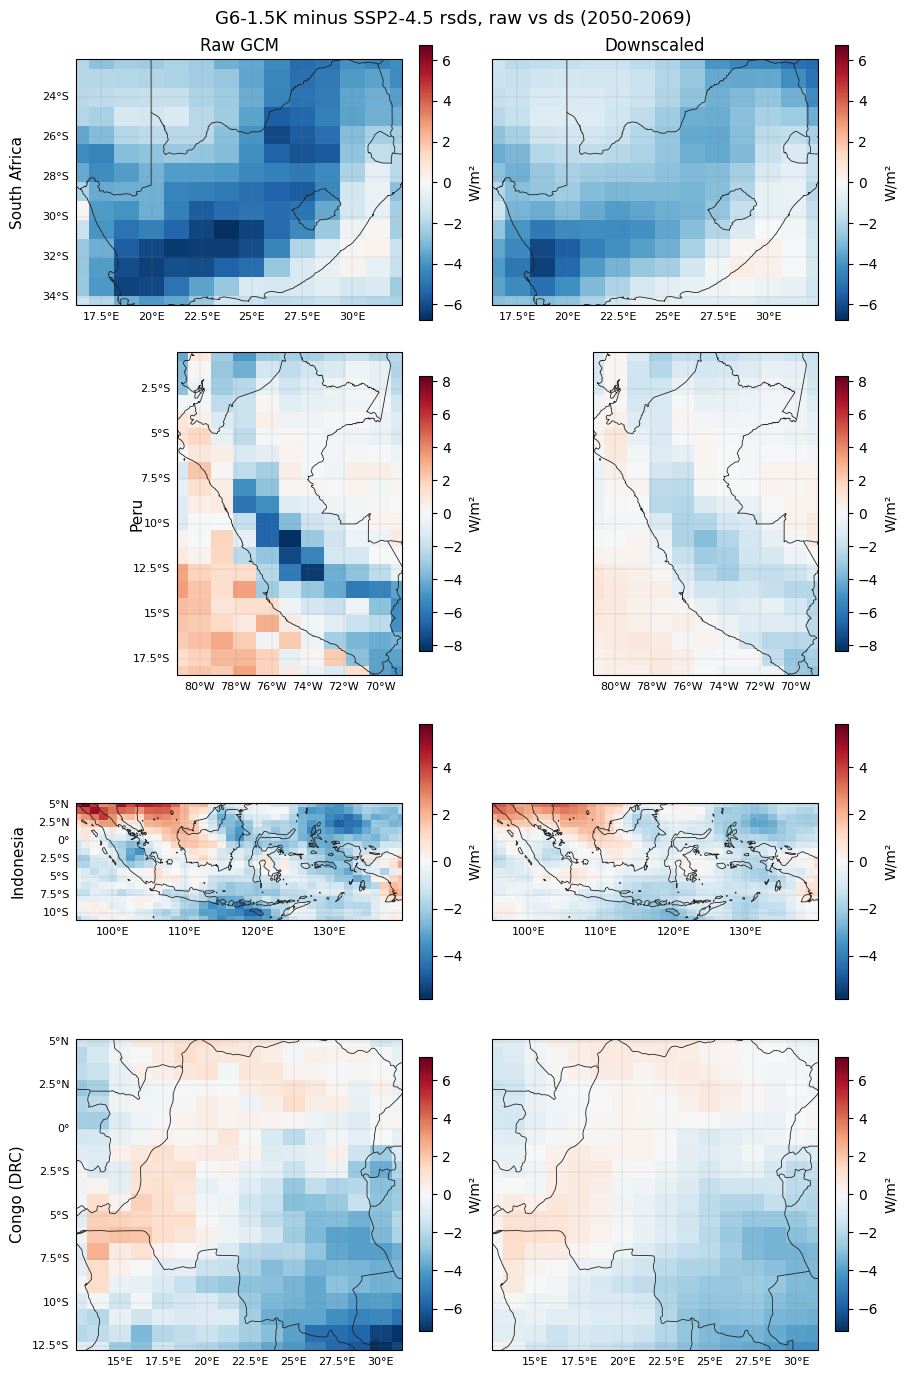

In [28]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

period = slice("2050-01-01", "2069-12-31")


def diff_field(g6_dict, ssp_dict, name):
    g6 = g6_dict[name].sel(time=period).mean("time")
    ssp = ssp_dict[name].sel(time=period).mean("time")
    return g6 - ssp


raw_diff = {name: diff_field(region_raw_g6, region_raw_ssp, name) for name in regions}
ds_diff = {name: diff_field(region_g6, region_ssp, name) for name in regions}

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    len(regions),
    2,
    figsize=(9, 3.4 * len(regions)),
    subplot_kw={"projection": proj},
    constrained_layout=True,
)
axes = np.atleast_2d(axes)

for i, name in enumerate(regions):
    r, d = raw_diff[name], ds_diff[name]
    vmax = float(np.nanmax(np.abs([r.values, d.values])))
    for j, (field, col) in enumerate([(r, "Raw GCM"), (d, "Downscaled")]):
        ax = axes[i, j]
        im = ax.pcolormesh(
            field.lon,
            field.lat,
            field.values,
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
            shading="auto",
            transform=proj,
        )
        ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="#222")
        ax.coastlines(linewidth=0.6, color="#222")
        ax.set_extent(
            [
                float(field.lon.min()),
                float(field.lon.max()),
                float(field.lat.min()),
                float(field.lat.max()),
            ],
            crs=proj,
        )

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = j == 0
        gl.xlabel_style = {"size": 8}
        gl.ylabel_style = {"size": 8}

        fig.colorbar(im, ax=ax, shrink=0.85, label="W/m²")
        if i == 0:
            ax.set_title(col, fontsize=12)
        if j == 0:
            ax.text(
                -0.18,
                0.5,
                name,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=11,
                fontweight="500",
            )

fig.suptitle("G6-1.5K minus SSP2-4.5 rsds, raw vs ds (2050-2069)", fontsize=13, y=1.005)
plt.show()

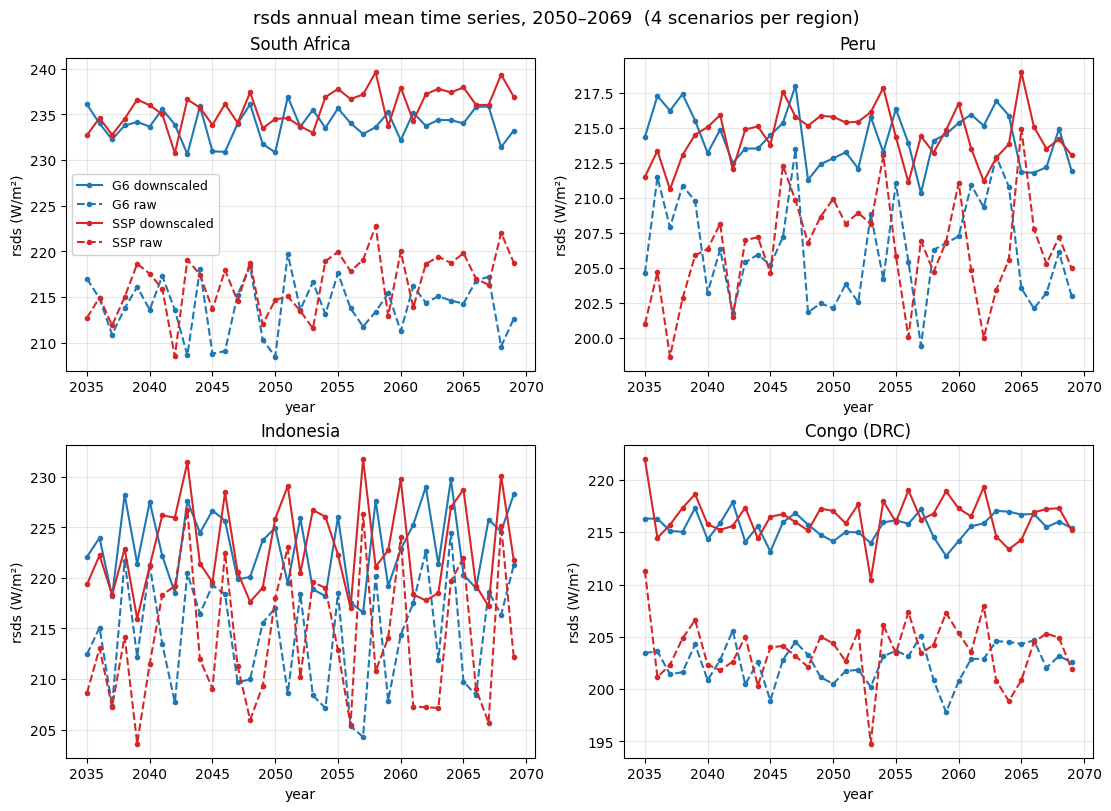

In [32]:
import matplotlib.pyplot as plt
import numpy as np

period = slice("2035-01-01", "2069-12-31")


def annual_mean_ts(da):
    """Area-weighted region mean, then annual mean -> one value per year."""
    w = np.cos(np.deg2rad(da.lat))
    ts = da.sel(time=period).weighted(w).mean(("lat", "lon"))
    return ts.resample(time="YS").mean()


series = {
    "G6 downscaled": region_g6,
    "G6 raw": region_raw_g6,
    "SSP downscaled": region_ssp,
    "SSP raw": region_raw_ssp,
}
style = {
    "G6 downscaled": dict(color="#1f77b4", ls="-"),
    "G6 raw": dict(color="#1f77b4", ls="--"),
    "SSP downscaled": dict(color="#d62728", ls="-"),
    "SSP raw": dict(color="#d62728", ls="--"),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, name in zip(axes.flat, regions):
    for label, d in series.items():
        ts = annual_mean_ts(d[name])
        ax.plot(ts["time"].dt.year, ts.values, label=label, marker="o", ms=3, **style[label])
    ax.set_title(name, fontsize=12, fontweight="500")
    ax.set_xlabel("year")
    ax.set_ylabel("rsds (W/m²)")
    ax.grid(alpha=0.3)

axes.flat[0].legend(fontsize=9, framealpha=0.9)
fig.suptitle("rsds annual mean time series, 2050–2069  (4 scenarios per region)", fontsize=13)
plt.show()

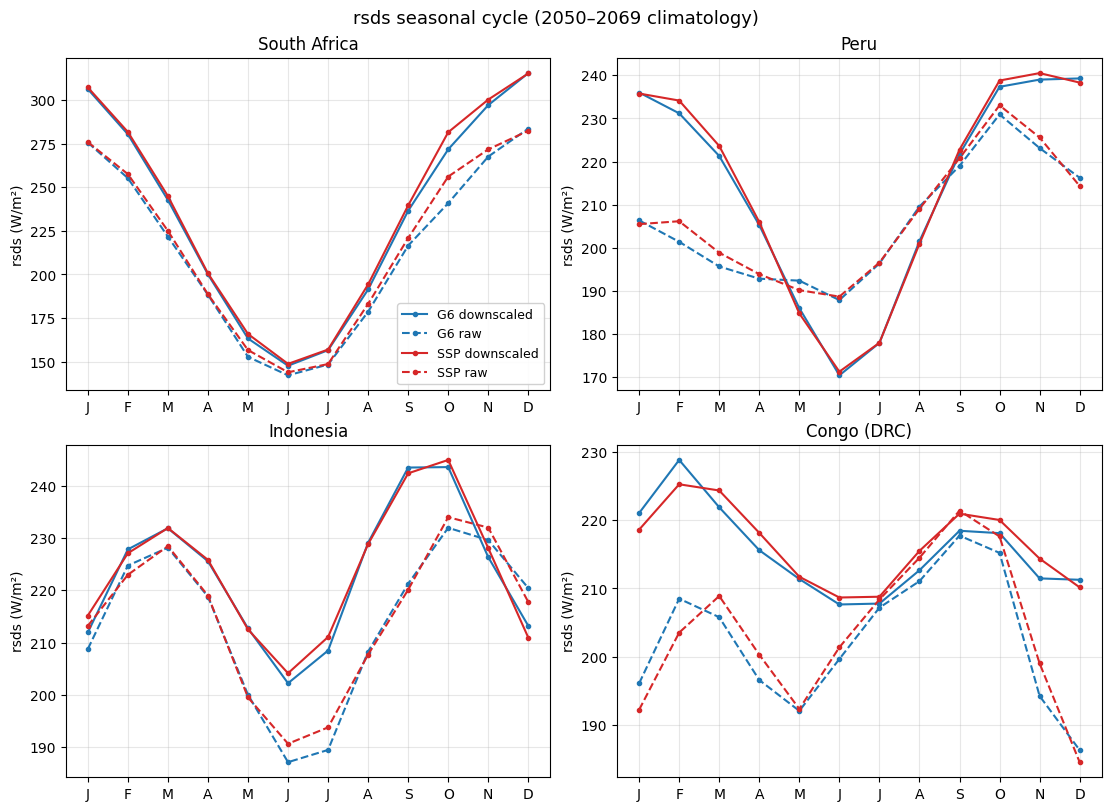

In [29]:
import matplotlib.pyplot as plt
import numpy as np

period = slice("2050-01-01", "2069-12-31")


def seasonal_cycle(da):
    """Area-weighted region mean, then climatological monthly cycle over the period."""
    w = np.cos(np.deg2rad(da.lat))
    ts = da.sel(time=period).weighted(w).mean(("lat", "lon"))
    return ts.groupby("time.month").mean()


series = {
    "G6 downscaled": region_g6,
    "G6 raw": region_raw_g6,
    "SSP downscaled": region_ssp,
    "SSP raw": region_raw_ssp,
}
style = {
    "G6 downscaled": dict(color="#1f77b4", ls="-"),
    "G6 raw": dict(color="#1f77b4", ls="--"),
    "SSP downscaled": dict(color="#d62728", ls="-"),
    "SSP raw": dict(color="#d62728", ls="--"),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, name in zip(axes.flat, regions):
    for label, d in series.items():
        cyc = seasonal_cycle(d[name])
        ax.plot(cyc["month"], cyc.values, label=label, marker="o", ms=3, **style[label])
    ax.set_title(name, fontsize=12, fontweight="500")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_ylabel("rsds (W/m²)")
    ax.grid(alpha=0.3)

axes.flat[0].legend(fontsize=9, framealpha=0.9)
fig.suptitle("rsds seasonal cycle (2050–2069 climatology)", fontsize=13)
plt.show()

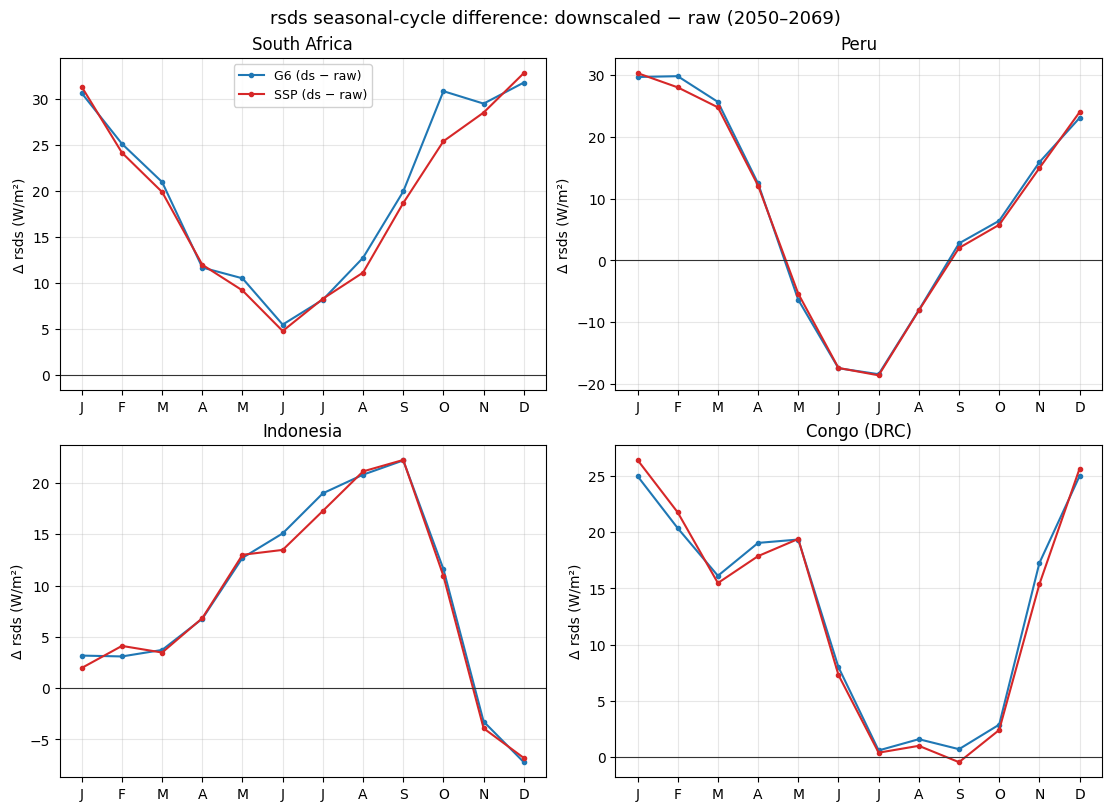

In [33]:
import matplotlib.pyplot as plt
import numpy as np

period = slice("2050-01-01", "2069-12-31")


def seasonal_cycle(da):
    """Area-weighted region mean, then climatological monthly cycle over the period."""
    w = np.cos(np.deg2rad(da.lat))
    ts = da.sel(time=period).weighted(w).mean(("lat", "lon"))
    return ts.groupby("time.month").mean()


diff_style = {
    "G6 (ds − raw)": dict(color="#1f77b4", ls="-"),
    "SSP (ds − raw)": dict(color="#d62728", ls="-"),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, name in zip(axes.flat, regions):
    g6_diff = seasonal_cycle(region_g6[name]) - seasonal_cycle(region_raw_g6[name])
    ssp_diff = seasonal_cycle(region_ssp[name]) - seasonal_cycle(region_raw_ssp[name])
    ax.plot(
        g6_diff["month"],
        g6_diff.values,
        label="G6 (ds − raw)",
        marker="o",
        ms=3,
        **diff_style["G6 (ds − raw)"],
    )
    ax.plot(
        ssp_diff["month"],
        ssp_diff.values,
        label="SSP (ds − raw)",
        marker="o",
        ms=3,
        **diff_style["SSP (ds − raw)"],
    )
    ax.axhline(0, color="#333", lw=0.8)  # zero = downscaling changed nothing
    ax.set_title(name, fontsize=12, fontweight="500")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_ylabel("Δ rsds (W/m²)")
    ax.grid(alpha=0.3)

axes.flat[0].legend(fontsize=9, framealpha=0.9)
fig.suptitle("rsds seasonal-cycle difference: downscaled minus raw (2050–2069)", fontsize=13)
plt.show()

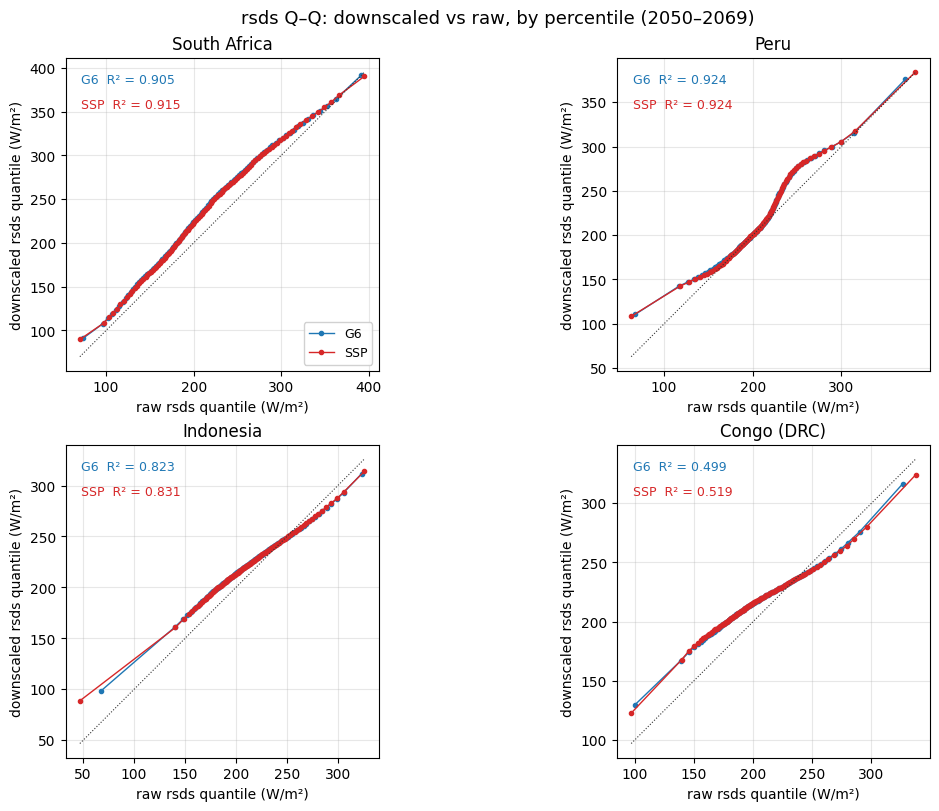

In [37]:
import matplotlib.pyplot as plt
import numpy as np

period = slice("2050-01-01", "2069-12-31")


def sample(da):
    v = da.sel(time=period).values.ravel()
    return v[np.isfinite(v)]


q = np.linspace(0, 100, 101)

qq_style = {
    "G6": dict(color="#1f77b4"),
    "SSP": dict(color="#d62728"),
}


def r2(x, y):
    """R² of y against x (coefficient of determination about the 1:1 line)."""
    ss_res = np.sum((y - x) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot


fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, name in zip(axes.flat, regions):
    pairs = {
        "G6": (region_raw_g6[name], region_g6[name]),
        "SSP": (region_raw_ssp[name], region_ssp[name]),
    }
    lo, hi = np.inf, -np.inf
    r2_txt = []
    for label, (raw_da, ds_da) in pairs.items():
        qr = np.percentile(sample(raw_da), q)
        qd = np.percentile(sample(ds_da), q)
        ax.plot(qr, qd, marker="o", ms=3, lw=1, label=label, **qq_style[label])
        lo = min(lo, qr.min(), qd.min())
        hi = max(hi, qr.max(), qd.max())
        r2_txt.append((label, r2(qr, qd), qq_style[label]["color"]))

    ax.plot([lo, hi], [lo, hi], color="#333", lw=0.8, ls=":")
    ax.set_aspect("equal")

    for k, (label, val, color) in enumerate(r2_txt):
        ax.text(
            0.05,
            0.95 - 0.08 * k,
            f"{label}  R² = {val:.3f}",
            transform=ax.transAxes,
            color=color,
            fontsize=9,
            va="top",
            ha="left",
            fontweight="500",
        )

    ax.set_title(name, fontsize=12, fontweight="500")
    ax.set_xlabel("raw rsds quantile (W/m²)")
    ax.set_ylabel("downscaled rsds quantile (W/m²)")
    ax.grid(alpha=0.3)

axes.flat[0].legend(fontsize=9, framealpha=0.9, loc="lower right")
fig.suptitle("rsds Q–Q: downscaled vs raw, by percentile (2050–2069)", fontsize=13)
plt.show()

In [38]:
training_period = slice("1985-01-01", "2014-12-31")
variables = ["rsds"]

In [40]:
era5 = catalog.get("ERA5").to_xarray()
era5 = era5[variables].sel(time=training_period)

In [41]:
raw_hist = (
    catalog.get(gcm)
    .to_xarray(group=SCENARIO_GROUPS["historical"])[variables]
    .sel(ensemble_member="001")
)

In [44]:
raw_hist_mon = (
    raw_hist["rsds"].sel(time=slice("1980-01-01", "2014-12-31")).resample(time="MS").mean()
)

hist_reg = {
    name: region_box_subset(raw_hist_mon, r["lat"], r["lon"]).compute()
    for name, r in regions.items()
}

period = slice("2050-01-01", "2069-12-31")

In [46]:
def oos_count(fut_da, hist_da):
    """Per-cell historical [1st, 99th] envelope; count future (cell x month) points outside it."""
    lo = hist_da.quantile(0.01, dim="time")
    hi = hist_da.quantile(0.99, dim="time")
    fut = fut_da.sel(time=period)
    outside = (fut < lo) | (fut > hi)
    n_out = int(outside.sum().values)
    n_total = int(outside.count().values)
    return n_out, n_total


# Out-of-sample check: what % of future (2050–2069) monthly rsds cells fall outside the
# per-cell 1st–99th percentile envelope of 1980–2014 historical rsds — G6 vs SSP, per region

print(f"{'region':<15}{'G6 out/total':>20}{'G6 %':>8}{'SSP out/total':>20}{'SSP %':>8}")
for name in regions:
    g6_out, g6_tot = oos_count(region_raw_g6[name], hist_reg[name])
    ssp_out, ssp_tot = oos_count(region_raw_ssp[name], hist_reg[name])
    print(
        f"{name:<15}"
        f"{f'{g6_out}/{g6_tot}':>20}{100 * g6_out / g6_tot:>7.2f}%"
        f"{f'{ssp_out}/{ssp_tot}':>20}{100 * ssp_out / ssp_tot:>7.2f}%"
    )

region                 G6 out/total    G6 %       SSP out/total   SSP %
South Africa              913/47040   1.94%           904/47040   1.92%
Peru                      894/52800   1.69%           854/52800   1.62%
Indonesia               3246/159840   2.03%         3124/159840   1.95%
Congo (DRC)              1585/76800   2.06%          1644/76800   2.14%
